In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# Task 4: Classification with Logistic Regression

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the Breast Cancer Wisconsin dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (569, 30)
Target shape: (569,)


In [4]:
# Display basic information about the dataset

print("First 5 rows:")
display(X.head())

print("\nTarget classes:")
print(y.value_counts())

print("\nMissing values:")
print(X.isnull().sum().sum())

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target classes:
target
1    357
0    212
Name: count, dtype: int64

Missing values:
0


In [5]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [6]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized successfully!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Features standardized successfully!
Training data shape: (455, 30)
Testing data shape: (114, 30)


In [7]:
# Train the Logistic Regression model

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [8]:
# Make predictions on the test data

y_pred = model.predict(X_test_scaled)

print("Predictions made successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions made successfully!
First 10 predictions:
[0 1 0 1 0 1 1 0 0 0]


In [9]:
# Get probability predictions

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predicted probabilities:")
print(y_prob[:10])

First 10 predicted probabilities:
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]


Confusion Matrix:
[[41  1]
 [ 1 71]]


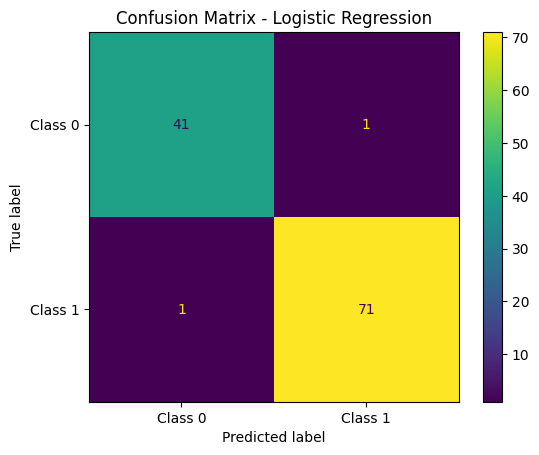

In [10]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display the confusion matrix visually
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [11]:
# Calculate Precision and Recall

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Precision: 0.9861
Recall: 0.9861


In [12]:
# Calculate ROC-AUC

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9954


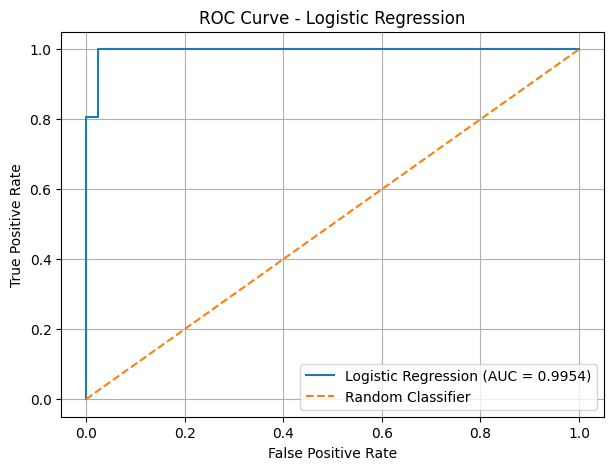

In [13]:
# Plot ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()

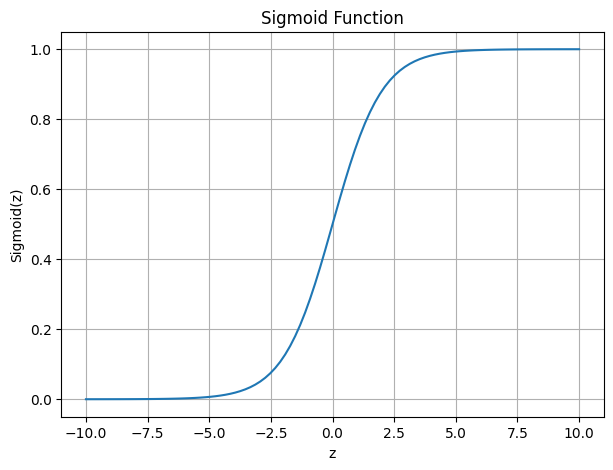

In [14]:
# Sigmoid Function

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)

plt.figure(figsize=(7, 5))
plt.plot(z, sigmoid(z))

plt.xlabel("z")
plt.ylabel("Sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid()
plt.show()

In [15]:
# Threshold Tuning

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds_to_test:
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    
    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print("-" * 30)

Threshold: 0.3
Precision: 0.9730
Recall:    1.0000
------------------------------
Threshold: 0.4
Precision: 0.9861
Recall:    0.9861
------------------------------
Threshold: 0.5
Precision: 0.9861
Recall:    0.9861
------------------------------
Threshold: 0.6
Precision: 0.9855
Recall:    0.9444
------------------------------
Threshold: 0.7
Precision: 0.9853
Recall:    0.9306
------------------------------


In [16]:
# Compare Precision and Recall at Different Thresholds

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for threshold in thresholds_to_test:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall
    })

threshold_results = pd.DataFrame(results)

display(threshold_results)

,Threshold,Precision,Recall
0,0.3,0.972973,1.000000
1,0.4,0.986111,0.986111
2,0.5,0.986111,0.986111
3,0.6,0.985507,0.944444
4,0.7,0.985294,0.930556


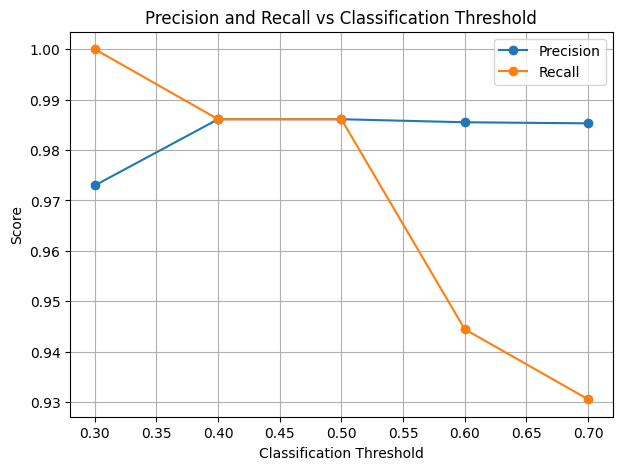

In [17]:
# Plot Precision and Recall for Different Thresholds

plt.figure(figsize=(7, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.legend()
plt.grid()
plt.show()

In [18]:
# Final Classification Report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Class 0", "Class 1"]
))

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.98      0.98        42
     Class 1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [19]:
# Final Model Performance Summary

print("===== Logistic Regression Performance =====")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print("==========================================")

===== Logistic Regression Performance =====
Precision : 0.9861
Recall    : 0.9861
ROC-AUC   : 0.9954


## Conclusion

In this task, a Logistic Regression model was developed for binary classification using the Breast Cancer Wisconsin dataset.

The dataset was divided into training and testing sets, and the features were standardized using StandardScaler. The Logistic Regression model was then trained on the standardized training data.

The model was evaluated using a confusion matrix, precision, recall, and ROC-AUC. The ROC curve was also plotted to analyze the model's ability to distinguish between the two classes.

The sigmoid function was studied to understand how Logistic Regression converts the model's output into a probability between 0 and 1.

Finally, different classification thresholds were tested to observe their effect on precision and recall. The threshold can be adjusted depending on whether precision or recall is more important for a particular application.

Overall, the Logistic Regression model achieved strong classification performance on the test dataset.
